# Experiment - No-show rate 

> **Takeaway -** A no-show is a *separate* empty-room risk (no cancellation event, frees only the remaining nights), so it feeds the overbooking allowance and occupancy view, not the cancellation model.

## In plain words
A **no-show** empties a room like a cancellation, but you only find out at arrival (no time to resell well), and only the *remaining* nights of the stay can be recovered. It is a fundamentally different event from a cancellation, so it lives outside the cancellation model. Here we measure **how often** it happens and **for whom**, so it can feed the overbooking allowance separately.

## What we're testing
The historical no-show rate = `NoShow / (bookings that reached arrival without cancelling)`, sliced by channel, lead time, length-of-stay, refundability and region, plus a *freed-inventory* view that ties a no-show's value to how many nights it frees (the "27-night no-show frees ~26 nights" point).

In [1]:
import sys
from pathlib import Path
_here = Path.cwd().resolve()
while not (_here / "pyproject.toml").exists() and _here != _here.parent:
    _here = _here.parent
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from src import load_reservations, apply_stayery_style, figures_dir, add_country_region
apply_stayery_style()
OUT = figures_dir() / "experiments"; OUT.mkdir(parents=True, exist_ok=True)

df = load_reservations()                       # raw, all statuses incl. NoShow
for col in ["arrival", "departure", "created"]:
    df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

# Same window as the model (floor + future cutoff) for a comparable rate.
FLOOR  = pd.Timestamp("2022-08-01", tz="UTC")
CUTOFF = pd.Timestamp.now("UTC").normalize() - pd.Timedelta(days=3)
df = df[(df["arrival"] >= FLOOR) & (df["arrival"] < CUTOFF)].copy()

# Population that REACHED arrival without cancelling (the no-show denominator).
reached = df[df["status"].isin(["CheckedOut", "InHouse", "NoShow"])].copy()
reached["noshow"] = (reached["status"] == "NoShow").astype(int)
print(f"reached-arrival bookings: {len(reached):,} | no-shows: {reached['noshow'].sum():,} "
      f"| overall no-show rate: {reached['noshow'].mean():.2%}")

# Slicing features (lightweight; raw columns).
reached["lead_days"] = ((reached["arrival"].dt.normalize() - reached["created"].dt.normalize())
                        / pd.Timedelta(days=1)).clip(lower=0)
reached["los"] = ((reached["departure"].dt.normalize() - reached["arrival"].dt.normalize())
                  / pd.Timedelta(days=1)).clip(lower=1)
reached["lead_bucket"] = pd.cut(reached["lead_days"], [-1,7,30,90,10**9], labels=["0-7d","8-30d","31-90d","90d+"])
reached["los_bucket"]  = pd.cut(reached["los"], [0,2,6,13,10**9], labels=["1-2","3-6","7-13","14+"])
ch = reached["channelCode"].astype("string"); src = reached["source"].astype("string")
reached["channel"] = ch.mask((ch=="ChannelManager") & src.notna() & (src.str.len()>0), src)
reached["is_nonref"] = (reached["ratePlan_name"].astype("string").fillna("")
                        .str.contains(r"non.?ref|nrf|prepaid|nicht.*erstatt", case=False, regex=True).astype(int))
add_country_region(reached)
print("slicing features ready")

loading cached parquet: reservations_raw_no_pii.parquet


reached-arrival bookings: 139,135 | no-shows: 1,893 | overall no-show rate: 1.36%
slicing features ready


## 1 - No-show rate by segment

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


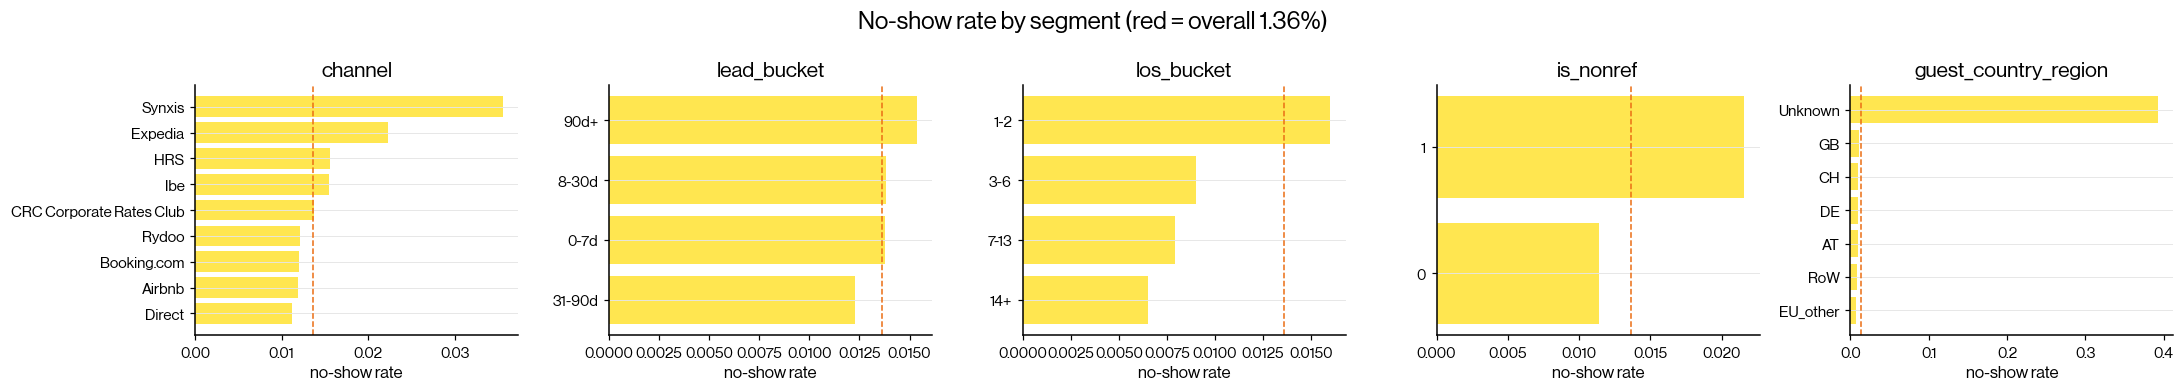


[channel]
                 channel  rate     n
                  Synxis 0.036   759
                 Expedia 0.022  5569
                     HRS 0.016  8571
                     Ibe 0.015 37293
CRC Corporate Rates Club 0.014   583
                   Rydoo 0.012   247
             Booking.com 0.012 59673
                  Airbnb 0.012  5493
                  Direct 0.011 20413

[lead_bucket]
lead_bucket  rate     n
       90d+ 0.015  6448
      8-30d 0.014 42994
       0-7d 0.014 65384
     31-90d 0.012 24309

[los_bucket]
los_bucket  rate     n
       1-2 0.016 95017
       3-6 0.009 29756
      7-13 0.008  6673
       14+ 0.007  7689

[is_nonref]
 is_nonref  rate      n
         1 0.022  29987
         0 0.011 109148

[guest_country_region]
guest_country_region  rate      n
             Unknown 0.393   1620
                  GB 0.011   3161
                  CH 0.010   1952
                  DE 0.009 104838
                  AT 0.009   1384
                 RoW 0.008   9265
        

In [2]:
def rate_by(col, min_n=200):
    g = (reached.groupby(col, observed=True)["noshow"]
         .agg(rate="mean", n="size").reset_index())
    return g[g["n"] >= min_n].sort_values("rate", ascending=False)

slices = ["channel", "lead_bucket", "los_bucket", "is_nonref", "guest_country_region"]
fig, axes = plt.subplots(1, len(slices), figsize=(4*len(slices), 3.6))
overall = reached["noshow"].mean()
for ax, col in zip(axes, slices):
    g = rate_by(col)
    ax.barh(g[col].astype(str), g["rate"], color="C0")
    ax.axvline(overall, color="C3", ls="--", lw=1)
    ax.set_title(col); ax.set_xlabel("no-show rate")
    ax.invert_yaxis()
fig.suptitle(f"No-show rate by segment (red = overall {overall:.2%})")
fig.tight_layout(); fig.savefig(OUT / "noshow_rate_by_segment.png", dpi=130, bbox_inches="tight")
plt.show()
for col in slices:
    print(f"\n[{col}]"); print(rate_by(col).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

## 2 - Freed inventory (why length-of-stay matters)

A no-show frees its *remaining* nights. So the inventory a no-show returns scales with length-of-stay - a long-stay no-show is worth far more to overbooking than a short one. Expected freed room-nights per booking = `no-show rate x LOS`.

no-shows: 1,893 | median LOS 1 nights | total room-nights freed (gross): 4,991

expected freed room-nights per booking by LOS bucket:
los_bucket  noshow_rate  mean_los  exp_freed_nights     n
       1-2        0.016     1.317             0.019 95017
       3-6        0.009     3.729             0.034 29756
      7-13        0.008     8.914             0.071  6673
       14+        0.007    37.588             0.221  7689


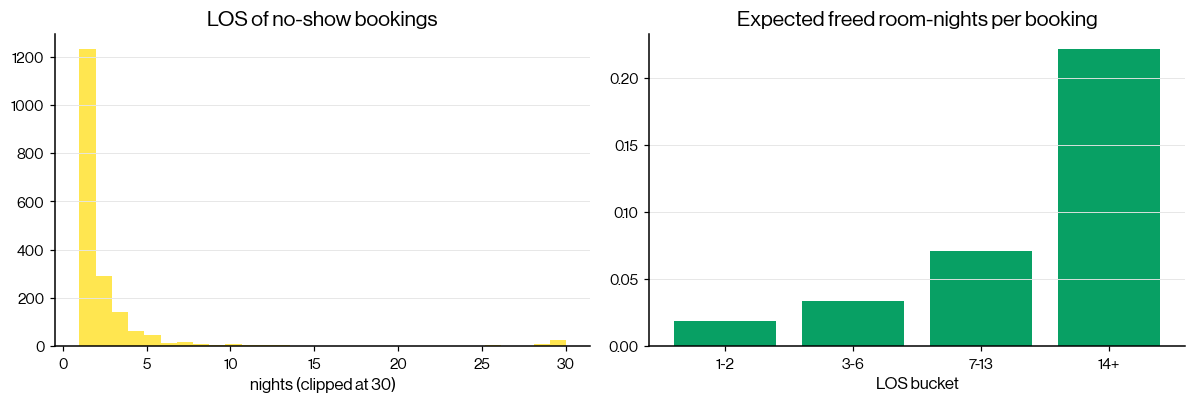

In [3]:
ns = reached[reached["noshow"]==1]
print(f"no-shows: {len(ns):,} | median LOS {ns['los'].median():.0f} nights | "
      f"total room-nights freed (gross): {int(ns['los'].sum()):,}")

# expected freed room-nights per booking, by LOS bucket
g = (reached.assign(freed=reached["noshow"]*reached["los"])
     .groupby("los_bucket", observed=True)
     .agg(noshow_rate=("noshow","mean"), mean_los=("los","mean"),
          exp_freed_nights=("freed","mean"), n=("noshow","size")).reset_index())
print("\nexpected freed room-nights per booking by LOS bucket:")
print(g.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(ns["los"].clip(upper=30), bins=30, color="C0")
ax[0].set_title("LOS of no-show bookings"); ax[0].set_xlabel("nights (clipped at 30)")
ax[1].bar(g["los_bucket"].astype(str), g["exp_freed_nights"], color="C2")
ax[1].set_title("Expected freed room-nights per booking"); ax[1].set_xlabel("LOS bucket")
fig.tight_layout(); fig.savefig(OUT / "noshow_freed_inventory.png", dpi=130, bbox_inches="tight")
plt.show()

## Takeaways

The No-Show rate is so incredibly low and does not seem to show a clear pattern. For now these bookings will not be included in considerations. When the No-Show occurred, the future occupancy will be updated accordingly anyways. Most no shows are short stays (and mostly non refundable stays)